## SNOTEL QC Development
Evaluate some approaches to doing QC on SNOTEL data.

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, time
from buildforcing.datasets import PNNLSnotel
import os

In [2]:
site = 'Baldy'

### Load Data
I only care about the range of data used in the downscaling, so I'll limit the data to that range using the find_usable_dates function from buildforcing.

In [3]:
snotel = PNNLSnotel(site_name=site, storage_path=os.environ['SNOTEL_PATH'])
snotel.load_data()

# print latitude and longitude for reference
print(f"Latitude: {snotel.latitude}, Longitude: {snotel.longitude}")

Latitude: 33.98, Longitude: -109.5


In [4]:
start_date, end_date = snotel.find_usable_dates()
print(f"Usable dates: {start_date} to {end_date}")

Usable dates: 1988-09-27 to 2021-09-30


In [5]:
# Extract SNOTEL data for the usable date range or starting in 1990, whichever is later
if start_date < date(1990, 1, 1):
    start_date = date(1990, 1, 1)

snotel_data = snotel.data[start_date.strftime('%Y-%m-%d'):end_date.strftime('%Y-%m-%d')]

I think most of the datasets are daily with Nans for missing data, but it seems reasonable to ensure that is the case.

In [6]:
# Ensure index is daily
snotel_data = snotel_data.asfreq('D')

#### Visualization

In [7]:
# Calculate F temperatures for easier analysis
snotel_data['T_max_F'] = snotel_data['T_max_C'] * 9/5 + 32
snotel_data['T_min_F'] = snotel_data['T_min_C'] * 9/5 + 32
snotel_data['T_avg_F'] = snotel_data['T_avg_C'] * 9/5 + 32

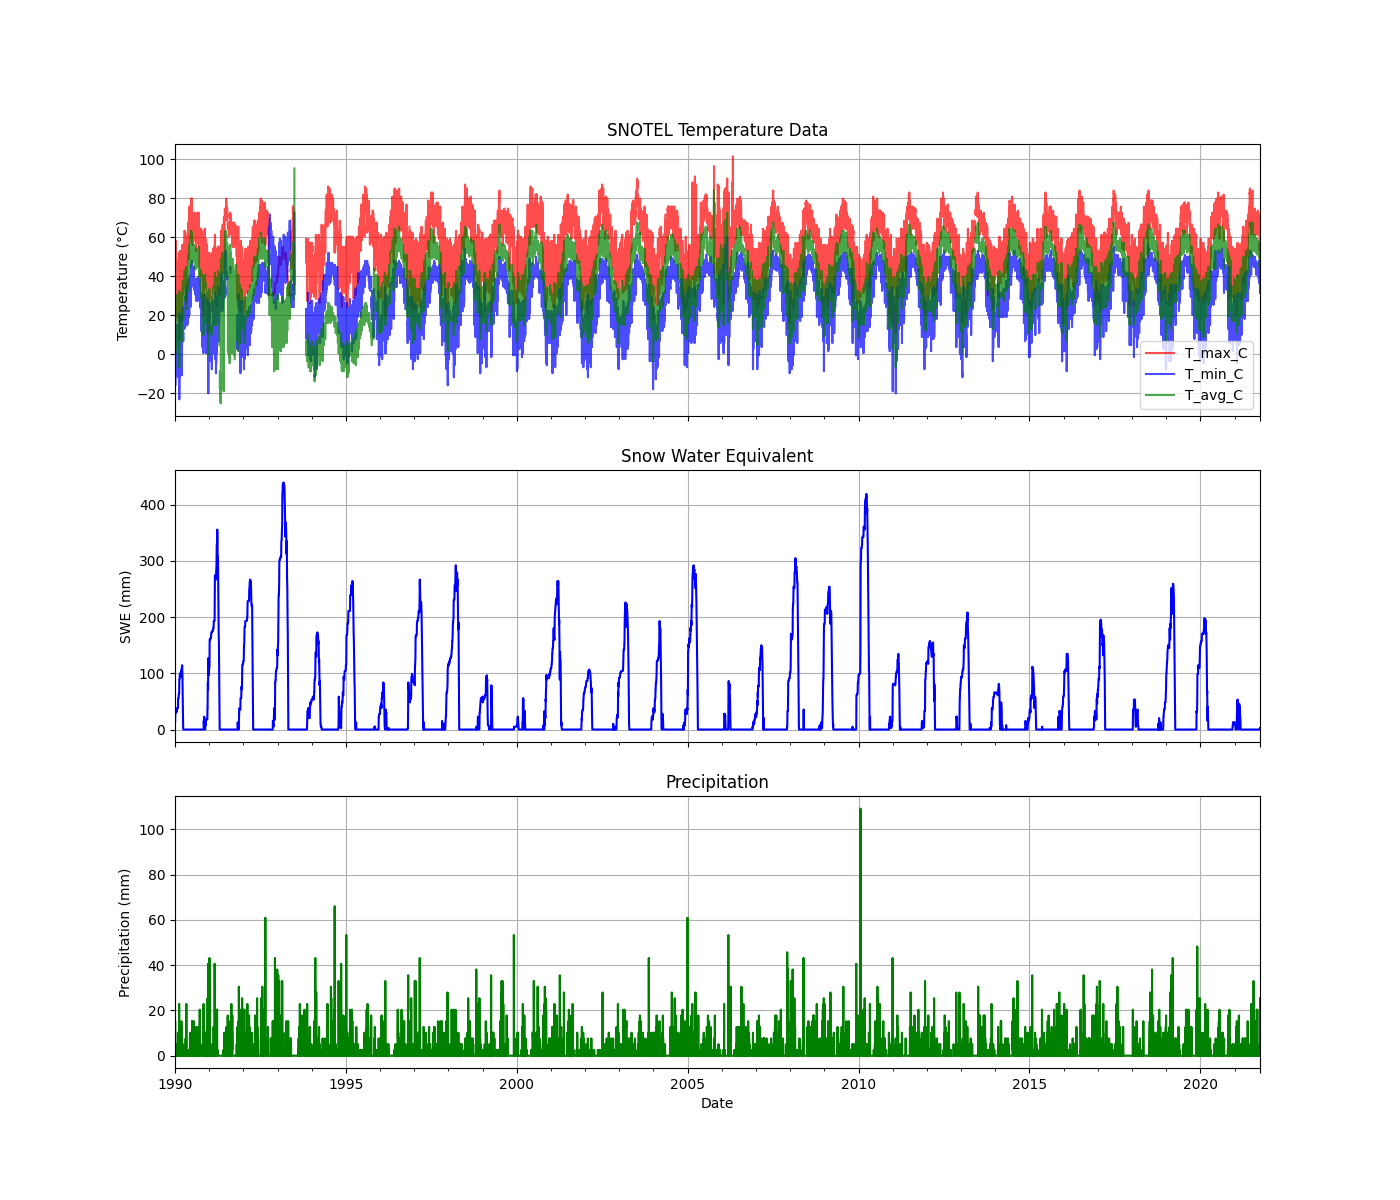

In [8]:
# Create a single figure with 3 subplots (temperature, SWE, precipitation)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot temperatures in the top subplot
snotel_data['T_max_F'].plot(ax=ax1, label='T_max_C', color='red', alpha=0.7)
snotel_data['T_min_F'].plot(ax=ax1, label='T_min_C', color='blue', alpha=0.7)
snotel_data['T_avg_F'].plot(ax=ax1, label='T_avg_C', color='green', alpha=0.7)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('SNOTEL Temperature Data')
ax1.legend()
ax1.grid(True)

# Plot SWE in the middle subplot
ax2.plot(snotel_data.index, snotel_data['swe_mm'], color='blue')
ax2.set_ylabel('SWE (mm)')
ax2.set_title('Snow Water Equivalent')
ax2.grid(True)

# Plot Precipitation in the bottom subplot
ax3.plot(snotel_data.index, snotel_data['precip_mm'], color='green')
ax3.set_xlabel('Date')
ax3.set_ylabel('Precipitation (mm)')
ax3.set_title('Precipitation')
ax3.grid(True)

plt.show()

## QC Testing

Extract sections of interest for manual review.

In [9]:
test_start = '2005-01-01'
test_end = '2006-12-31'
test_section = snotel_data.loc[test_start:test_end, ['T_max_C', 'T_min_C', 'T_avg_C']]

In [10]:
from buildforcing import snotelQC
from buildforcing.datasets import siteNLDAS

Flag test data

In [11]:
test_flags = snotelQC.qc_maxmin_temperatures(test_section[['T_max_C', 'T_min_C']], outlier_std=2.0)

In [12]:
# Create series of clean data
snotel_Tmax_clean = test_section['T_max_C'].where(~test_flags['Tmax_bad'])
snotel_Tmin_clean = test_section['T_min_C'].where(~test_flags['Tmin_bad'])

Fill data using NLDAS

In [13]:
nldas_data = siteNLDAS(snotel.latitude, snotel.longitude, start_date=datetime.strptime(test_start, '%Y-%m-%d'), end_date=datetime.strptime(test_end, '%Y-%m-%d'))

In [14]:
nldas_data.loadNetCDF(os.environ['NLDAS_PATH'])

In [15]:
nldas_data.data.tail()

,LWdown,PSurf,Qair,Rainf,SWdown,Tair,Wind_E,Wind_N
Date&Time,,,,,,,,
2006-12-30 20:00:00+00:00,199.45,72355.3,0.003169,0.000,517.782,269.74,1.41,-5.47
2006-12-30 21:00:00+00:00,194.05,72333.0,0.003209,0.180,484.784,270.45,2.76,-5.15
2006-12-30 22:00:00+00:00,194.03,72413.1,0.003006,0.000,362.880,269.74,2.43,-5.23
2006-12-30 23:00:00+00:00,194.02,72493.1,0.002804,0.236,216.312,269.03,2.09,-5.31
2006-12-31 00:00:00+00:00,173.49,72572.9,0.002602,0.000,27.844,268.33,1.76,-5.39


In [16]:
# Generate filled data for comparison
snotel_Tmax_filled = snotelQC.fill_T_nldas(snotel_Tmax_clean, nldas_T_data=nldas_data.data['Tair'])
snotel_Tmin_filled = snotelQC.fill_T_nldas(snotel_Tmin_clean, nldas_T_data=nldas_data.data['Tair'])

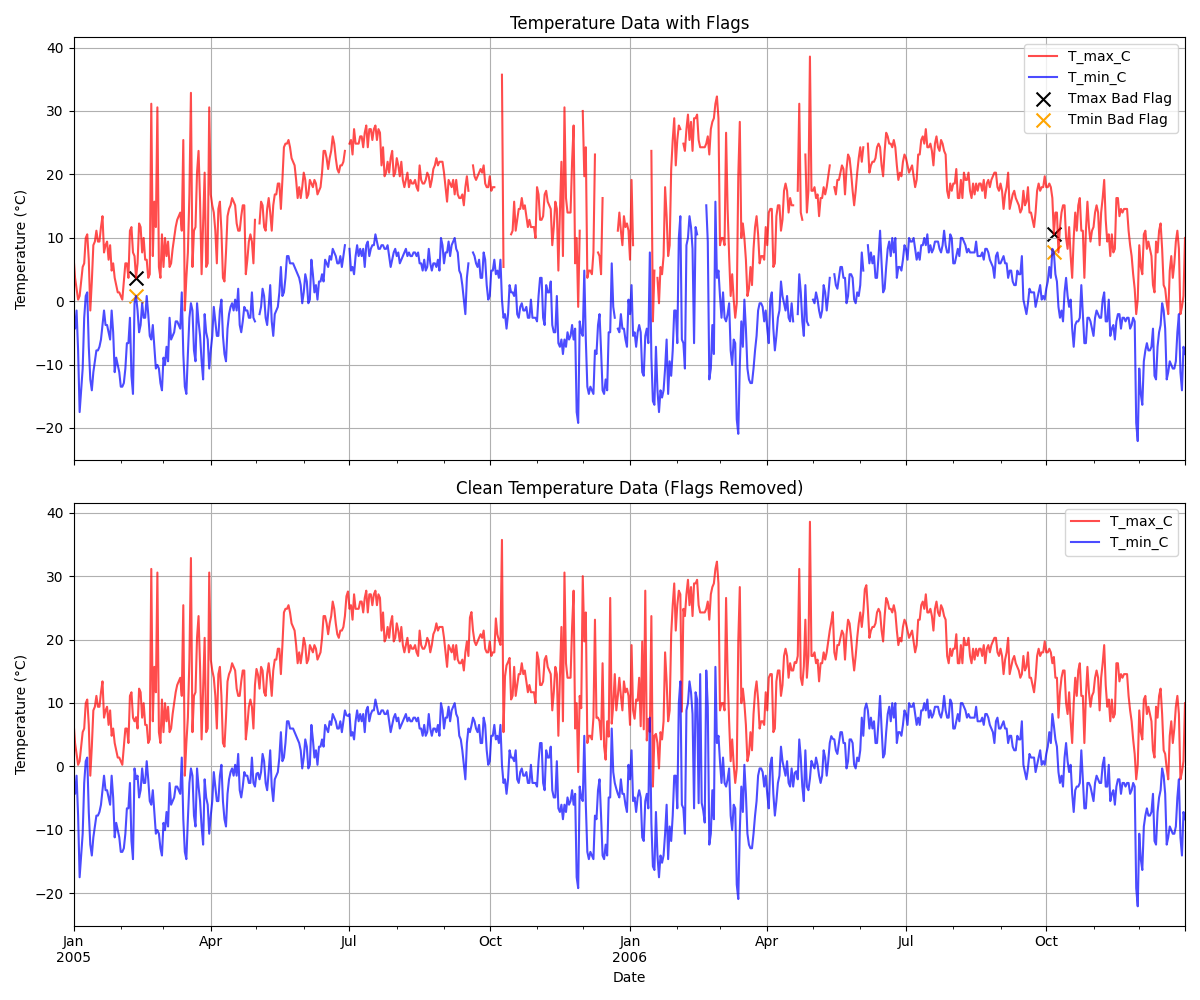

In [17]:
# Plot test section with flags and clean data in two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot test section with flags in the top subplot
test_section['T_max_C'].plot(ax=ax1, label='T_max_C', color='red', alpha=0.7)
test_section['T_min_C'].plot(ax=ax1, label='T_min_C', color='blue', alpha=0.7)
ax1.scatter(test_section.index[test_flags['Tmax_bad']], test_section['T_max_C'][test_flags['Tmax_bad']], color='black', marker='x', s=100, label='Tmax Bad Flag')
ax1.scatter(test_section.index[test_flags['Tmin_bad']], test_section['T_min_C'][test_flags['Tmin_bad']], color='orange', marker='x', s=100, label='Tmin Bad Flag')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature Data with Flags')
ax1.legend()
ax1.grid(True)

# Plot clean data in the bottom subplot
snotel_Tmax_filled.plot(ax=ax2, label='T_max_C', color='red', alpha=0.7)
snotel_Tmin_filled.plot(ax=ax2, label='T_min_C', color='blue', alpha=0.7)
ax2.set_ylabel('Temperature (°C)')
ax2.set_xlabel('Date')
ax2.set_title('Clean Temperature Data (Flags Removed)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

Test detrending

In [18]:
test_section['T_max_C_detrended'] = snotelQC.detrend_seasonal_cycle(test_section['T_max_C'])

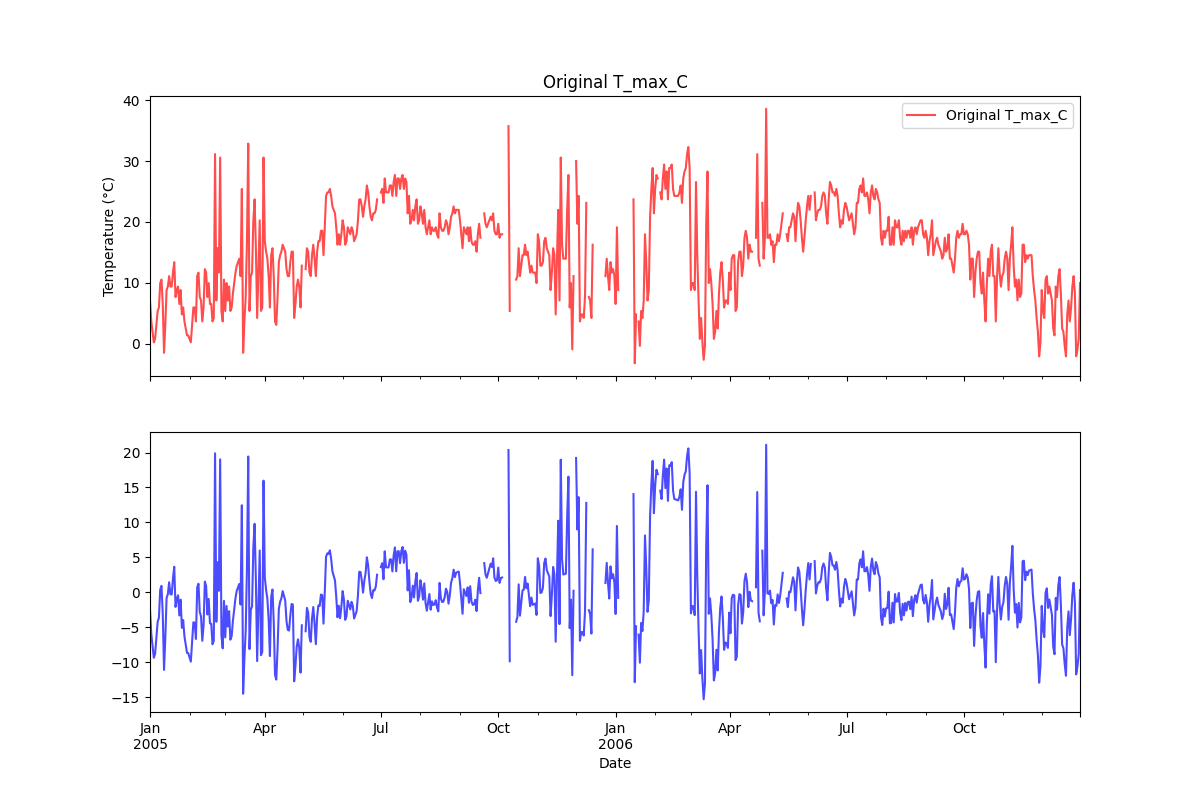

In [19]:
# Plot detrended data and original for comparison in subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
test_section['T_max_C'].plot(ax=ax1, label='Original T_max_C', color='red', alpha=0.7)
test_section['T_max_C_detrended'].plot(ax=ax2, label='Detrended T_max_C', color='blue', alpha=0.7)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Original T_max_C')
ax1.legend()

In [20]:
test_section['T_max_C_detrended'].describe()

count    6.920000e+02
mean    -2.226093e-14
std      6.068317e+00
min     -1.531616e+01
25%     -3.193727e+00
50%     -6.279578e-01
75%      2.371299e+00
max      2.111374e+01
Name: T_max_C_detrended, dtype: float64